# Sliding-window feature occlusion pre radar časové rady

Tento notebook nadväzuje na `Explainer_time_series.ipynb`, ale namiesto IG a GradCAM používa iba **lokálnu oklúziu po okne v čase**.

Myšlienka:
- vyberie sa jedna feature,
- prekryje sa len malé časové okno danej feature,
- sleduje sa pokles skóre cieľovej triedy,
- výsledok sa akumuluje do hustej mapy **feature × time**,
- dole sa zobrazí aj **globálne prekrytie po čase** naprieč všetkými feature.

Nastaviteľné parametre:
- `WINDOW_SIZE`
- `STRIDE`
- `OCCLUSION_VALUE`
- `MODE`
- `KEEP_NEGATIVE`


In [1]:

# Ak by chýbala knižnica:
# %pip install scikit-image

import sys
from pathlib import Path
import importlib
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import gridspec

import torch
import torch.nn as nn

ROOT = Path.cwd()
PROJECT_DIR = ROOT / "DetekciaOdpaduMiniProjekt"

if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

print("ROOT:", ROOT)
print("PROJECT_DIR exists:", PROJECT_DIR.exists())


ROOT: C:\Users\tvysi\PycharmProjects\GradCamIntegration
PROJECT_DIR exists: True


In [2]:

import SensorNormalizer, WindowedLeBasedDataset, TrainingRadar, Networks
from DataLoader import DataLoaderProprietary
import DataViewModel
from DataViewModel import LoadedDataViewModel
from Occlusion.Occlusion import Occlusion

importlib.reload(WindowedLeBasedDataset)
importlib.reload(SensorNormalizer)
importlib.reload(TrainingRadar)
importlib.reload(Networks)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


Using device: cuda


In [3]:

loaded_data_view_model: LoadedDataViewModel = DataLoaderProprietary.load_all_data(
    load_from_csv_files=False,
    file_name=str(PROJECT_DIR / "final_dataset_nove_vozidla_2"),
    load_video_annotations=True
)

LoadedDataViewModel.add_dummy_messages(loaded_data_view_model.vehicles)

vehicle_split_commands = []
vehicle_split_commands.append(DataViewModel.TestVehicleSplitComand(1.0, "ZA196JN_video"))
vehicle_split_commands.append(DataViewModel.TestVehicleSplitComand(1.0, "ZA234JG_video"))
vehicle_split_commands.append(DataViewModel.TestVehicleSplitComand(1.0, "ZA503JU_video"))

loaded_data_view_model.normalizer = SensorNormalizer.SensorNormalizer(
    True,
    False,
    [
        "axis_x_acc",
        "axis_y_acc",
        "axis_z_acc",
        "sig_pwr",
    ]
)

loaded_data_view_model.split_to_train_and_test(vehicle_split_commands)

train_dataset = WindowedLeBasedDataset.WindowedLeBasedDataset(
    loaded_data_view_model.train_vehicles, 25 * 2, 'train', 25
)
test_dataset = WindowedLeBasedDataset.WindowedLeBasedDataset(
    loaded_data_view_model.test_vehicles, 25 * 2, 'test', 25
)

print("Train dataset size:", len(train_dataset))
print("Test dataset size:", len(test_dataset))


SensorNormalizer: ignore_rfid = False , use_left_right_arm_info = True , field_names = None
Bola spustena inicializacia dat
Celkovy pocet data messages : 0
Celkovy pocet vysypov: 0
split b les between car arms
remove bad les
Spustam nacitanie dat
Spúšťam načítanie loaded data viewmodelu
Nacitanie dokoncene
Pridavam dummy messages
Hotovo
SensorNormalizer: ignore_rfid = True , use_left_right_arm_info = False , field_names = ['axis_x_acc', 'axis_y_acc', 'axis_z_acc', 'sig_pwr']
Vozidlo s ecv: ZA127IR bolo zaradene do trenovacej mnoziny
Vozidlo s ecv: ZA234JG bolo zaradene do trenovacej mnoziny
Vozidlo s ecv: ZA255KC bolo zaradene do trenovacej mnoziny
Vozidlo s ecv: ZA346KA bolo zaradene do trenovacej mnoziny
Vozidlo s ecv: ZA499JN bolo zaradene do trenovacej mnoziny
Vozidlo s ecv: AA619SP bolo zaradene do trenovacej mnoziny
Vozidlo s ecv: AA713KN bolo zaradene do trenovacej mnoziny
Vozidlo s ecv: BT155HT bolo zaradene do trenovacej mnoziny
Vozidlo s ecv: BT874HR bolo zaradene do trenovac

In [4]:

patience = 50
train = False

FINAL_DROPOUT = 0.2
FINAL_WEIGHT_DECAY = 1e-3
FINAL_B1_MULTIPLIER = 3.0
FINAL_B2_MULTIPLIER = 5.0

model = Networks.CnnBaseNetworkRadar(10, 4, 50, dropout_rate=FINAL_DROPOUT)

trainer = TrainingRadar.TrainingRadar(
    model,
    str(PROJECT_DIR / "container_type_le_based_best"),
    1000,
    lr=3e-4,
    weight_decay=FINAL_WEIGHT_DECAY,
    device=device,
    class_weight_b1_multiplier=FINAL_B1_MULTIPLIER,
    class_weight_b2_multiplier=FINAL_B2_MULTIPLIER,
)

training_results = trainer.train(train_dataset, test_dataset, 4, train, patience, ["L", "R", "B1", "B2"])
model = training_results["model"]
model.eval()

print(type(model))


<class 'Networks.CnnBaseNetworkRadar'>


In [9]:

FEATURE_NAMES = ["axis_x_acc", "axis_y_acc", "axis_z_acc", "sig_pwr", "mask"]
CLASS_NAMES = ["L", "R", "B1", "B2"]


def extract_true_label(label):
    if torch.is_tensor(label):
        if label.numel() == 1:
            return int(label.item())
        return int(torch.argmax(label).item())
    return int(label)


def sample_to_feature_time(sample: torch.Tensor) -> torch.Tensor:
    """Return tensor in shape [features, time]."""
    x = sample.detach().cpu()
    if x.dim() != 2:
        raise ValueError(f"Expected 2D sample, got shape {tuple(x.shape)}")
    if x.shape[0] > x.shape[1]:
        x = x.T
    return x


def run_model_on_sample(model: nn.Module, sample: torch.Tensor):
    model.eval()
    device = next(model.parameters()).device

    x = sample_to_feature_time(sample).unsqueeze(0).to(device)  # [1, C, T]

    with torch.no_grad():
        output = model(x)
        probs = torch.softmax(output, dim=1)
        pred_class = int(torch.argmax(probs, dim=1).item())
        confidence = float(probs[0, pred_class].item())

    return output, probs, pred_class, confidence


def _normalize_0_1(x: np.ndarray, eps: float = 1e-8) -> np.ndarray:
    x = np.asarray(x, dtype=np.float32)
    xmin = float(x.min())
    xmax = float(x.max())
    if xmax - xmin < eps:
        return np.zeros_like(x)
    return (x - xmin) / (xmax - xmin)


def prepare_heatmap_for_display(x: np.ndarray, clip_percentile: float = 98.0) -> np.ndarray:
    """Robust normalization for clearer heatmaps."""
    x = np.asarray(x, dtype=np.float32)
    out = np.zeros_like(x)

    if x.ndim == 1:
        hi = float(np.percentile(x, clip_percentile))
        row = np.clip(x, 0.0, hi)
        return _normalize_0_1(row)

    for i in range(x.shape[0]):
        row = x[i]
        hi = float(np.percentile(row, clip_percentile))
        row = np.clip(row, 0.0, hi)
        out[i] = _normalize_0_1(row)
    return out


def explain_sample_with_window_occlusion(
    model: nn.Module,
    sample: torch.Tensor,
    target_class: int | None = None,
    window_size: int = 2,
    stride: int = 1,
    occlusion_value: str | float = "mean",
    mode: str = "prob_drop",
    keep_negative: bool = False,
    batch_size: int = 32,
):
    """
    Sliding-window feature occlusion implemented through Occlusion.explain_time_series().

    The original Occlusion.explain() remains unchanged for image inputs (1, C, H, W).
    This helper only adapts the sample to shape [1, C, T] and post-processes the outputs.
    """
    model.eval()
    device = next(model.parameters()).device

    feature_time = sample_to_feature_time(sample).float()   # [C, T]
    input_tensor = feature_time.unsqueeze(0).to(device)     # [1, C, T]

    explainer = Occlusion(model, device=device)
    occ_map_norm, orig_output, window_drops, window_starts, occ_map_raw = explainer.explain_time_series(
        input_tensor=input_tensor,
        target_class=target_class,
        window_size=window_size,
        stride=stride,
        occlusion_value=occlusion_value,
        mode=mode,
        batch_size=batch_size,
        keep_negative=keep_negative,
    )

    with torch.no_grad():
        orig_probs = torch.softmax(orig_output, dim=1)

    pred_class = int(torch.argmax(orig_probs, dim=1).item())
    if target_class is None:
        target_class = pred_class

    occ_map_norm, orig_output, window_drops, window_starts, occ_map_raw = explainer.explain_time_series(
        input_tensor=input_tensor,
        target_class=target_class,
        window_size=window_size,
        stride=stride,
        occlusion_value=occlusion_value,
        mode=mode,
        batch_size=batch_size,
        keep_negative=keep_negative,
    )

    dense_scores = occ_map_raw.squeeze(0).detach().cpu().numpy()
    dense_scores_norm = prepare_heatmap_for_display(dense_scores, clip_percentile=98.0)
    row_scores = dense_scores.mean(axis=1)
    global_scores = dense_scores.sum(axis=0)

    window_scores = []
    starts_np = window_starts.detach().cpu().numpy()
    drops_np = window_drops.detach().cpu().numpy()
    for feat_idx in range(drops_np.shape[0]):
        for w_idx, start in enumerate(starts_np):
            end = int(start) + int(window_size)
            window_scores.append((feat_idx, int(start), end, float(drops_np[feat_idx, w_idx])))

    result = {
        "feature_time": feature_time.numpy(),
        "dense_scores": dense_scores,
        "dense_scores_norm": dense_scores_norm,
        "row_scores": row_scores,
        "row_scores_norm": _normalize_0_1(row_scores),
        "global_scores": global_scores,
        "global_scores_norm": prepare_heatmap_for_display(global_scores, clip_percentile=98.0),
        "window_scores": window_scores,
        "window_starts": starts_np,
        "window_size": int(window_size),
        "stride": int(stride),
        "target_class": int(target_class),
        "pred_class": pred_class,
        "confidence": float(orig_probs[0, pred_class].item()),
        "probs": orig_probs.detach().cpu(),
        "output": orig_output.detach().cpu(),
    }
    return result


def compute_grouped_ylims(feature_time, feature_names):
    ylims = {}
    lower_names = [str(name).lower() for name in feature_names]

    acc_idx = [
        i for i, name in enumerate(lower_names)
        if name in {"axis_x_acc", "axis_y_acc", "axis_z_acc"}
    ]

    if acc_idx:
        vals = feature_time[acc_idx, :]
        ymin = float(np.min(vals))
        ymax = float(np.max(vals))
        pad = 0.05 * max(ymax - ymin, 1e-8)
        shared = (ymin - pad, ymax + pad)
        for i in acc_idx:
            ylims[i] = shared

    for i in range(len(feature_names)):
        if i in ylims:
            continue
        vals = feature_time[i]
        ymin = float(np.min(vals))
        ymax = float(np.max(vals))
        pad = 0.05 * max(ymax - ymin, 1e-8)
        if ymax - ymin < 1e-8:
            pad = 0.1 if abs(ymax) < 1e-8 else 0.05 * abs(ymax)
        ylims[i] = (ymin - pad, ymax + pad)

    return ylims


def plot_time_series_explanations(
    feature_time,
    feature_scores=None,       # [C]
    feature_heatmaps=None,     # [C, T]
    global_attribution=None,   # [T]
    true_label=None,
    pred_class=None,
    confidence=None,
    feature_names=None,
    class_names=None,
    feature_cmap="jet",
    heatmap_cmap="jet",
    global_cmap="jet",
    feature_label="Attribution strength (normalized)",
    global_title="Window overlap",
    figsize_per_feature=3.0,
):
    feature_time = np.asarray(feature_time, dtype=np.float32)

    if feature_scores is not None:
        feature_scores = np.asarray(feature_scores, dtype=np.float32)

    if feature_heatmaps is not None:
        feature_heatmaps = np.asarray(feature_heatmaps, dtype=np.float32)

    if global_attribution is not None:
        global_attribution = np.asarray(global_attribution, dtype=np.float32)

    feature_names = feature_names or [f"feature_{i}" for i in range(feature_time.shape[0])]
    num_features = min(feature_time.shape[0], len(feature_names))
    feature_time = feature_time[:num_features]

    if feature_scores is not None:
        if feature_scores.ndim != 1:
            raise ValueError(f"feature_scores must have shape [C], got {feature_scores.shape}")
        num_features = min(num_features, feature_scores.shape[0])
        feature_time = feature_time[:num_features]
        feature_scores = feature_scores[:num_features]

    if feature_heatmaps is not None:
        if feature_heatmaps.ndim != 2:
            raise ValueError(f"feature_heatmaps must have shape [C, T], got {feature_heatmaps.shape}")
        num_features = min(num_features, feature_heatmaps.shape[0])
        feature_time = feature_time[:num_features]
        feature_heatmaps = feature_heatmaps[:num_features]

    if global_attribution is not None:
        if global_attribution.ndim != 1:
            raise ValueError(f"global_attribution must have shape [T], got {global_attribution.shape}")

    ylims = compute_grouped_ylims(feature_time, feature_names[:num_features])

    pred_text = class_names[pred_class] if class_names and pred_class is not None and pred_class < len(class_names) else pred_class
    true_text = class_names[true_label] if class_names and true_label is not None and true_label < len(class_names) else true_label

    n_outer_rows = num_features + (1 if global_attribution is not None else 0)

    fig = plt.figure(
        figsize=(16, figsize_per_feature * num_features + (1.2 if global_attribution is not None else 0.0)),
        constrained_layout=True
    )

    outer = gridspec.GridSpec(
        nrows=n_outer_rows,
        ncols=4,
        figure=fig,
        width_ratios=[3.0, 1.0, 18.0, 0.9],
        height_ratios=[1.0] * num_features + ([0.7] if global_attribution is not None else []),
        hspace=0.18,
        wspace=0.08,
    )

    prev_ax_ts = None
    main_im = None

    for i in range(num_features):
        ax_name = fig.add_subplot(outer[i, 0])
        ax_name.axis("off")
        ax_name.text(0.98, 0.5, feature_names[i], ha="right", va="center", fontsize=11)

        ax_score = fig.add_subplot(outer[i, 1])
        if feature_scores is not None:
            score_img = np.array([[feature_scores[i]]], dtype=np.float32)
            ax_score.imshow(
                score_img,
                cmap=feature_cmap,
                vmin=0.0,
                vmax=1.0,
                aspect="auto",
                interpolation="nearest"
            )
        ax_score.set_xticks([])
        ax_score.set_yticks([])
        for spine in ax_score.spines.values():
            spine.set_visible(False)

        if feature_heatmaps is not None:
            sub = outer[i, 2].subgridspec(2, 1, height_ratios=[5.0, 1.2], hspace=0.02)
            ax_ts = fig.add_subplot(sub[0], sharex=prev_ax_ts)
            ax_hm = fig.add_subplot(sub[1], sharex=ax_ts)
        else:
            ax_ts = fig.add_subplot(outer[i, 2], sharex=prev_ax_ts)
            ax_hm = None

        ax_ts.plot(feature_time[i], linewidth=1.9)
        ax_ts.set_ylim(*ylims[i])
        ax_ts.grid(True, alpha=0.28)
        ax_ts.margins(x=0, y=0.02)

        if i < num_features - 1 or global_attribution is not None:
            ax_ts.tick_params(axis="x", labelbottom=False)
        else:
            ax_ts.set_xlabel("Time step")

        if ax_hm is not None:
            band_hm = np.repeat(feature_heatmaps[i][None, :], 12, axis=0)
            main_im = ax_hm.imshow(
                band_hm,
                aspect="auto",
                cmap=heatmap_cmap,
                vmin=0.0,
                vmax=1.0,
                interpolation="nearest",
                origin="lower"
            )
            ax_hm.set_yticks([])
            ax_hm.margins(x=0, y=0)
            if i < num_features - 1 or global_attribution is not None:
                ax_hm.tick_params(axis="x", labelbottom=False)
            else:
                ax_hm.set_xlabel("Time step")
            for spine in ax_hm.spines.values():
                spine.set_visible(False)

        prev_ax_ts = ax_ts

    if global_attribution is not None:
        row = num_features

        ax_global_name = fig.add_subplot(outer[row, 0:2])
        ax_global_name.axis("off")
        ax_global_name.text(
            0.98, 0.5, global_title,
            ha="right", va="center", fontsize=11, fontweight="bold"
        )

        ax_global = fig.add_subplot(outer[row, 2], sharex=prev_ax_ts)
        band_global = np.repeat(global_attribution[None, :], 10, axis=0)
        ax_global.imshow(
            band_global,
            aspect="auto",
            cmap=global_cmap,
            vmin=0.0,
            vmax=1.0,
            interpolation="nearest",
            origin="lower"
        )
        ax_global.set_yticks([])
        ax_global.set_xlabel("Time step")
        ax_global.margins(x=0)
        for spine in ax_global.spines.values():
            spine.set_visible(False)

    if main_im is None:
        dummy = np.repeat(np.array([[0.0, 1.0]], dtype=np.float32), 10, axis=0)
        ax_dummy = fig.add_subplot(outer[:num_features, 3])
        main_im = ax_dummy.imshow(dummy, aspect="auto", cmap=feature_cmap, vmin=0.0, vmax=1.0)
        ax_dummy.remove()

    cbar_ax = fig.add_subplot(outer[:num_features, 3])
    cbar = fig.colorbar(main_im, cax=cbar_ax)
    cbar.set_label(feature_label)

    title_parts = []
    if true_text is not None:
        title_parts.append(f"True: {true_text}")
    if pred_text is not None:
        title_parts.append(f"Pred: {pred_text}")
    if confidence is not None:
        title_parts.append(f"Conf: {confidence:.3f}")

    fig.suptitle(" | ".join(title_parts), fontsize=13)
    plt.show()


Sample index: 0
Window size: 10
Stride: 1
True label: 0 L
Predicted class: 3 B2
Confidence: 0.5267


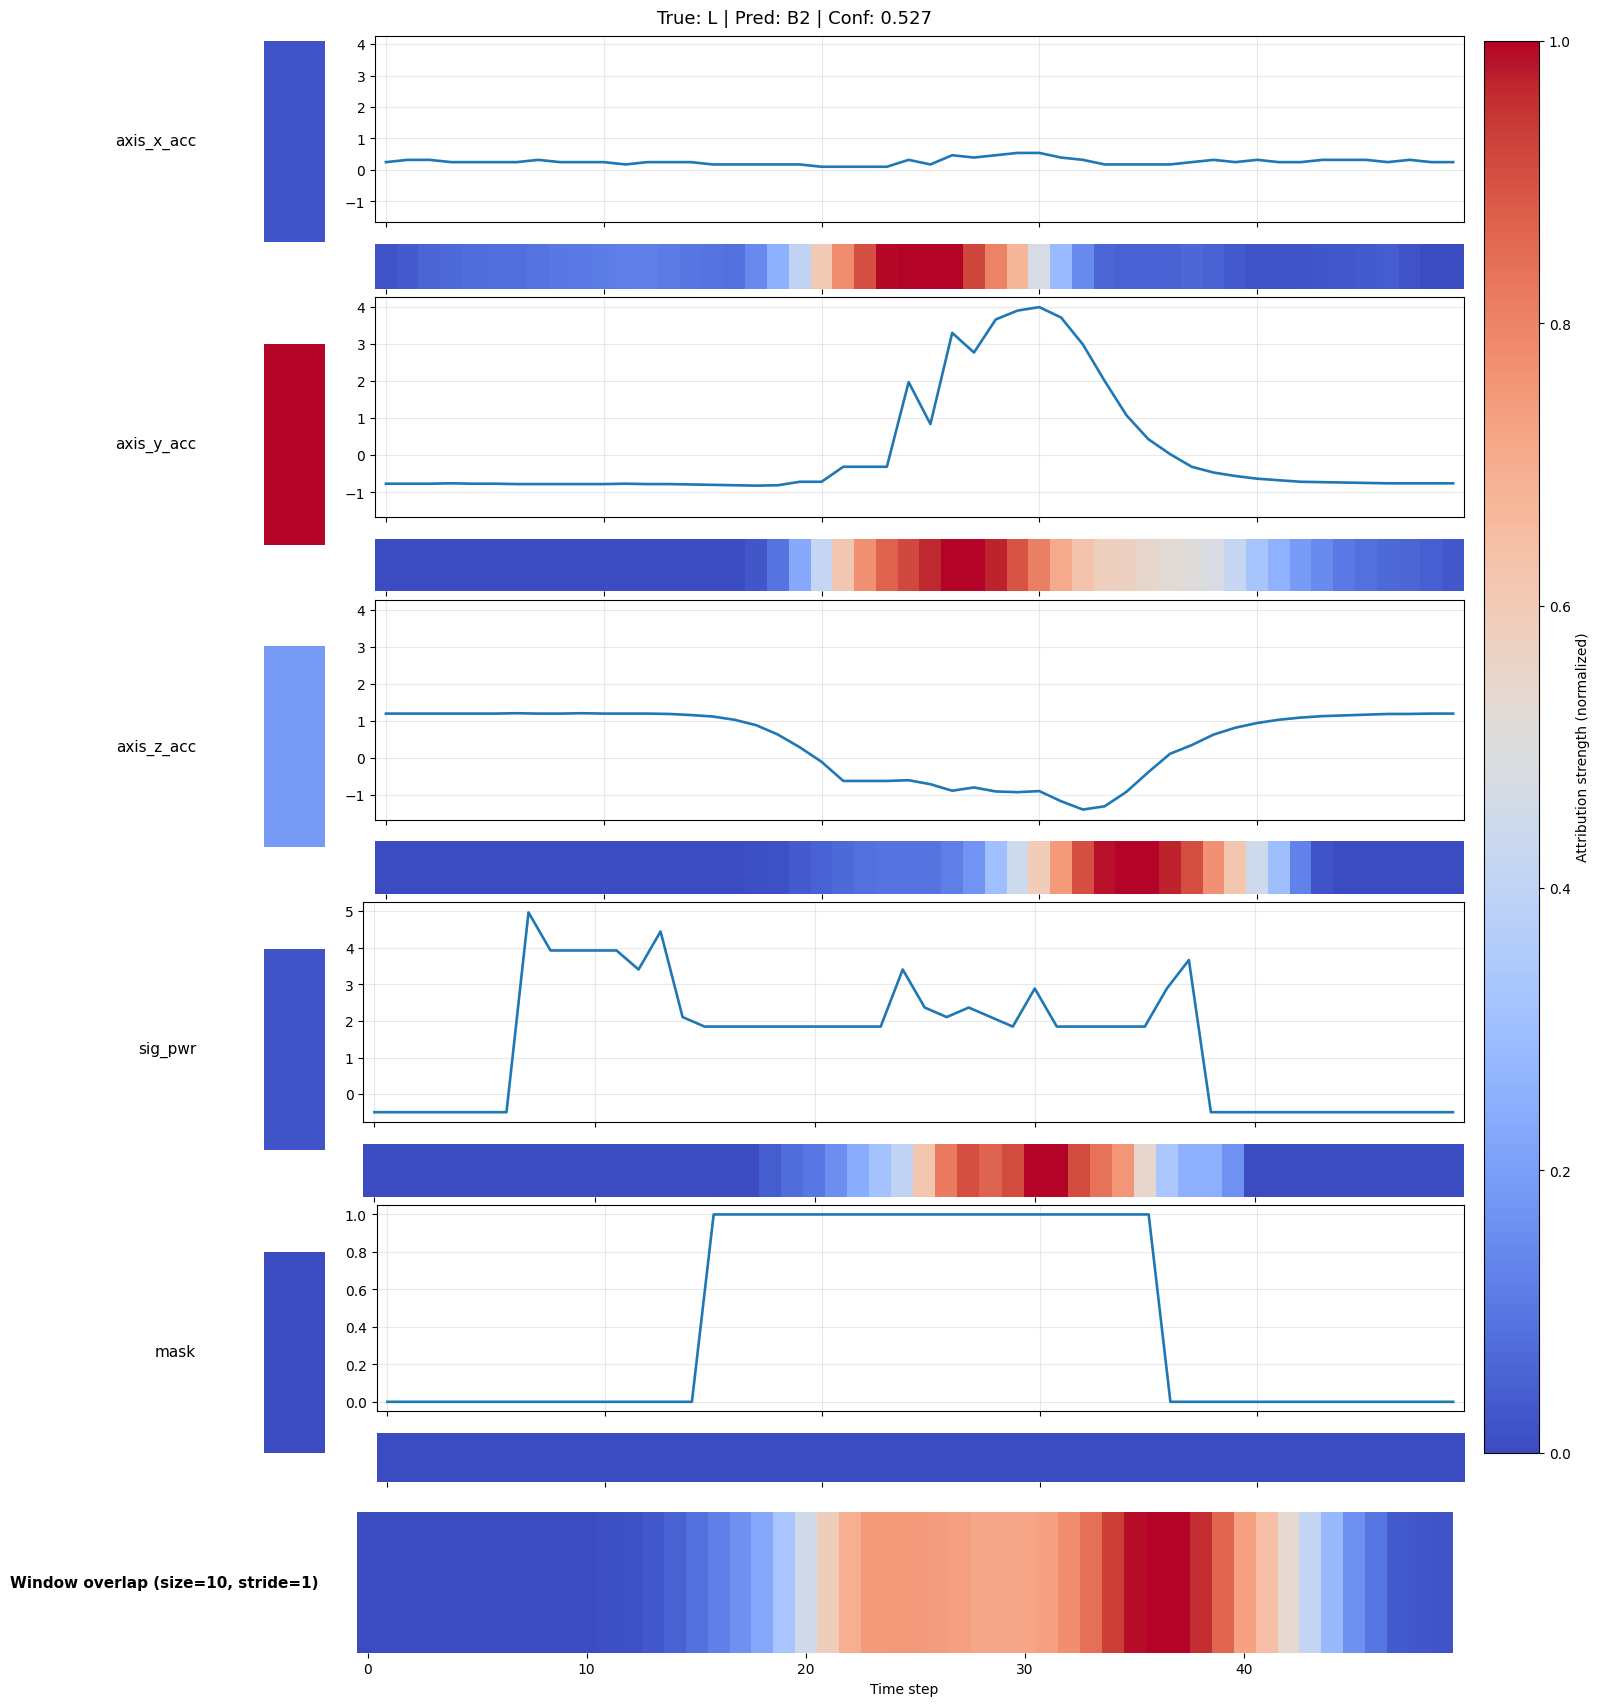

In [10]:

sample_idx = 0

WINDOW_SIZE = 10
STRIDE = 1
OCCLUSION_VALUE = "mean"   # "mean", "zero" alebo scalar
MODE = "prob_drop"         # "prob_drop" alebo "logit_drop"
KEEP_NEGATIVE = False

sample, label = test_dataset[sample_idx]
true_label = extract_true_label(label)

result = explain_sample_with_window_occlusion(
    model=model,
    sample=sample,
    target_class=None,
    window_size=WINDOW_SIZE,
    stride=STRIDE,
    occlusion_value=OCCLUSION_VALUE,
    mode=MODE,
    keep_negative=KEEP_NEGATIVE,
    batch_size=1
)

print("Sample index:", sample_idx)
print("Window size:", WINDOW_SIZE)
print("Stride:", STRIDE)
print("True label:", true_label, CLASS_NAMES[true_label] if true_label < len(CLASS_NAMES) else "")
print("Predicted class:", result["pred_class"], CLASS_NAMES[result["pred_class"]] if result["pred_class"] < len(CLASS_NAMES) else "")
print("Confidence:", round(result["confidence"], 4))

plot_time_series_explanations(
    feature_time=result["feature_time"],
    feature_scores=result["row_scores_norm"],
    feature_heatmaps=result["dense_scores_norm"],
    global_attribution=result["global_scores_norm"],
    true_label=true_label,
    pred_class=result["pred_class"],
    confidence=result["confidence"],
    feature_names=FEATURE_NAMES,
    class_names=CLASS_NAMES,
    feature_cmap="coolwarm",
    heatmap_cmap="coolwarm",
    global_cmap="coolwarm",
    feature_label="Attribution strength (normalized)",
    global_title=f"Window overlap (size={WINDOW_SIZE}, stride={STRIDE})",
    figsize_per_feature=3.15,
)


In [20]:

print("Raw row scores:")
for i, s in enumerate(result["row_scores"]):
    name = FEATURE_NAMES[i] if i < len(FEATURE_NAMES) else f"feature_{i}"
    print(f"{name:>12}: {s:.6f}")

print("\nDense map shape:", result["dense_scores"].shape)
print("Global timeline shape:", result["global_scores"].shape)
print("Number of evaluated windows:", len(result["window_scores"]))


Raw row scores:
  axis_x_acc: 0.000672
  axis_y_acc: 0.042742
  axis_z_acc: 0.008049
     sig_pwr: 0.000866
        mask: 0.000000
   feature_5: 0.000165
   feature_6: 0.023855
   feature_7: 0.010684
   feature_8: 0.000000
   feature_9: 0.006322

Dense map shape: (10, 50)
Global timeline shape: (50,)
Number of evaluated windows: 410
